# Paper: depth scans, lineage subsets and prediction meshes

Evaluate saved GIN checkpoints for the exclusive **aligned** seven-marker panel; Unassigned is the original all-negative identity. This notebook never fits models, transforms, baselines or folds. It restores the paper study's exact checkpoints and validation membership.

Report both MSE and MAE in physical units. Every summary gives each eligible organoid equal weight, after averaging errors over the requested cells. Shaded bands/error bars are descriptive ±1 SEM across organoids, conditional on the fitted models. For subset models, compare **depths 0 and 2** and evaluate **all cells** and **only original identities retained as inputs**; missing input channels never relabel cells for evaluation. Baseline and all-marker reference scores use the exact same cells.

Regional plots reproduce the legacy analysis: nearest crypt distance s<.75 for crypt and .75≤s≤1.1 for neck. The old budded selection labels an entire organoid-region using its mean nearest-crypt signed neck shape <0. This is deliberately not the newer neck classifier or a per-crypt budded selection. Both subset depths use the depth-2 all-marker model as the common reference. Relative improvement is (baseline error − subset error)/(baseline error − all-marker error); crypt-minus-neck is the difference of those two region-specific quantities.

Figures and the tables needed to reproduce them are written under this study's depth_scan, lineage_subsets and prediction_meshes folders. Numerical prediction meshes are exported as VTP, using the fold that actually held out the exemplar; no split is changed to force its inclusion.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from functools import lru_cache
from IPython.display import display
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.artifacts.runs import AnalysisRun
from src.artifacts.bundle import load_bundle
from src.analysis.metrics.evaluation import prediction_table, organoid_mse_summary
from src.analysis.spatial.regions import signed_neck_regions
from src.artifacts.provenance import workflow_fingerprint
import gc

## Settings
Choose the study and plotting/export parameters before loading data or defining plots.

In [2]:
# Study and saved artifacts
STUDY_DIR = PROJECT_ROOT / 'paper_results/exclusive_lineages/paper_exclusive_20261006_153255'  # One explicit paper study; no latest-run discovery.
MANIFEST = json.loads((STUDY_DIR/'manifest.json').read_text())  # Exact training runs registered by this study.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Inference only; this notebook never trains.

# Physical units and reporting
CURVATURE_SCALE = 1e-4  # Native curvature to um^-2; squared errors use its square.
SUBSET_DEPTHS = [0, 2]  # Compare these depths for each marker subset.
DEPTHS = [0, 1, 2, 3, 4]  # Depth scan to evaluate.
CRYPT_MAX = .75  # Legacy crypt: nearest normalized distance below .75.
NECK_MAX = 1.1  # Legacy neck: .75 <= nearest normalized distance <= 1.1.
FIGURE_FORMATS = ['png', 'pdf']  # Raster preview and vector paper figure.
RECOMPUTE = False  # False reuses verified per-model metric caches if present.

# Prediction illustration
EXEMPLAR = 'organoid_day4p5_B03_144'  # Use its saved held-out fold automatically.
MESH_DEPTHS = [0, 2, 4]  # Compare these depths for all markers and LGR5-only inputs.
MESH_VIEW = dict(azim=-135, elev=50)  # Legacy initial camera.


# Uncertainty
BOOTSTRAP_SEED = 42  # Paired organoid bootstrap seed.
BOOTSTRAP_REPEATS = 500  # Resamples for descriptive intervals.

## Restore runs and verify the comparison
Compare the saved memberships, original identities and preprocessing. Metrics are computed on validation cells only; caches are specific to these immutable checkpoints.

In [3]:
main = AnalysisRun(MANIFEST['runs']['main'])
subsets = AnalysisRun(MANIFEST['runs']['subsets'])
for run in (main, subsets):
    assert (run.directory/'complete.json').is_file()
    assert run.settings['exclusive_markers'] and run.settings['dataset']=='after_cleanup'
    assert run.settings['sphericity_max']==.94
assert json.loads((main.directory/'splits.json').read_text()) == json.loads((subsets.directory/'splits.json').read_text())
cohort = load_bundle(main.directory/'cohort')
raw_graphs = cohort['raw_graphs']
marker_names = cohort['all_marker_names']
identity_names = marker_names + ['Unassigned']
DATA_DIR = PROJECT_ROOT/'training_data'/main.settings['dataset']
assert {'20250929','20251201'} == {str(g.meta['dataset']) for g in raw_graphs.values()}
assert not {'organoid_day4p5_B03_15','organoid_day4_A06_66'} & set(raw_graphs)
print(f'{len(raw_graphs)} organoids; {len(main.records)+len(subsets.records)} saved models; no fitting.')


908 organoids; 160 saved models; no fitting.


## Evaluation and figure helpers
Average squared and absolute physical errors over each organoid-region and cell scope, then summarize across organoids. The original full-panel identity determines scope membership.

In [4]:
def save_figure(fig, destination):
    destination.parent.mkdir(parents=True, exist_ok=True)
    for extension in FIGURE_FORMATS:
        fig.savefig(destination.with_suffix('.'+extension), dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def summarize(frame, columns, value):
    return organoid_mse_summary(frame, columns, value=value)

@lru_cache(maxsize=2000)
def annotation(oid):
    graph = raw_graphs[oid]
    result = signed_neck_regions(graph, DATA_DIR, crypt_max=CRYPT_MAX, neck_max=NECK_MAX)
    x = graph.x.detach().cpu().numpy()
    if not np.all(x.sum(1) <= 1):
        raise ValueError('Paper analysis requires exclusive original identities.')
    result['lineage'] = np.asarray(identity_names, dtype=object)[np.where(x.sum(1)>0, x.argmax(1), len(marker_names))]
    return result

def metric_rows(frame, record, retained, *, include_lineages=False):
    rows = []
    for oid, cells in frame.groupby('organoid_str', sort=False):
        cells = cells.sort_values('node')
        labels = annotation(oid).set_index('node').loc[cells.node]
        regions = {'full': np.ones(len(cells),bool),
                   'budded_crypt': ((labels.region=='crypt') & labels.budded).to_numpy(),
                   'budded_neck': ((labels.region=='neck') & labels.budded).to_numpy()}
        scopes = {'all_cells':np.ones(len(cells),bool), 'retained_lineages':labels.lineage.isin(retained).to_numpy()}
        if include_lineages:
            scopes.update({'lineage:'+name:(labels.lineage==name).to_numpy() for name in identity_names})
        for region, rmask in regions.items():
            for scope, cmask in scopes.items():
                mask = rmask & cmask
                if not mask.any():
                    continue
                error = cells.error.to_numpy()[mask]*CURVATURE_SCALE
                base = (cells.baseline_prediction-cells.y_true).to_numpy()[mask]*CURVATURE_SCALE
                rows.append(dict(key=record['key'], name=record['name'], subset=record['subset'],
                    depth=int(record['depth']), fold=int(record['fold']), seed=int(record['seed']),
                    signal=record['signal'], organoid_str=oid, region=region, scope=scope,
                    n_cells=int(mask.sum()), mse=float(np.mean(error**2)), mae=float(np.mean(abs(error))),
                    baseline_mse=float(np.mean(base**2)), baseline_mae=float(np.mean(abs(base)))))
    return pd.DataFrame(rows)

METRIC_LABELS = {'mse':r'MSE ($\mu$m$^{-4}$)', 'mae':r'MAE ($\mu$m$^{-2}$)'}


## Evaluate the saved depth and subset models
Retain compact per-organoid metric caches inside the training runs for resuming. Paper exports contain only tables actually used by the figures. All-marker models also provide per-lineage metrics for matching the reference to arbitrary retained-marker unions.

In [5]:
FINGERPRINT = workflow_fingerprint(PROJECT_ROOT/'experiments/paper/depth_and_lineage_evaluation.ipynb')
parts = []
for role, run in [('main',main),('subsets',subsets)]:
    cache = run.directory/'analysis'/'paper_cell_scope_metrics'/FINGERPRINT[:12]
    cache.mkdir(parents=True, exist_ok=True)
    for record in run.records.sort_values(['fold','subset','depth']).to_dict('records'):
        path = cache/f"{record['key']}.csv"
        if RECOMPUTE or not path.exists():
            selected = run.select(record['key'],device=DEVICE)
            predictions = prediction_table(selected,device=DEVICE)
            retained = identity_names if role=='main' else selected['marker_names']
            frame = metric_rows(predictions, record, retained, include_lineages=role=='main')
            frame.to_csv(path,index=False)
            del selected,predictions
            run._data_cache.clear()
        frame = pd.read_csv(path)
        frame['run_role'] = role
        parts.append(frame)
        print(role,record['key'],flush=True)
metrics = pd.concat(parts,ignore_index=True)
print('Metric units: MSE um^-4; MAE um^-2.')


main gin_all_intact_d0_h128_f0_s42


main gin_all_intact_d1_h128_f0_s42


main gin_all_intact_d2_h128_f0_s42


main gin_all_intact_d3_h128_f0_s42


main gin_all_intact_d4_h128_f0_s42


...

subsets gin_LGR5_EXO_intact_d0_h128_f4_s42


subsets gin_LGR5_EXO_intact_d2_h128_f4_s42


subsets gin_LGR5_EXO_ENDO_intact_d0_h128_f4_s42


subsets gin_LGR5_EXO_ENDO_intact_d2_h128_f4_s42


Metric units: MSE um^-4; MAE um^-2.


## Depth scan: all cells and LGR5-positive cells
Compare all-marker and LGR5-input-only models at depths 0–4. Each scope has its own matching baseline. Curves show equal-organoid means with ±1 SEM.

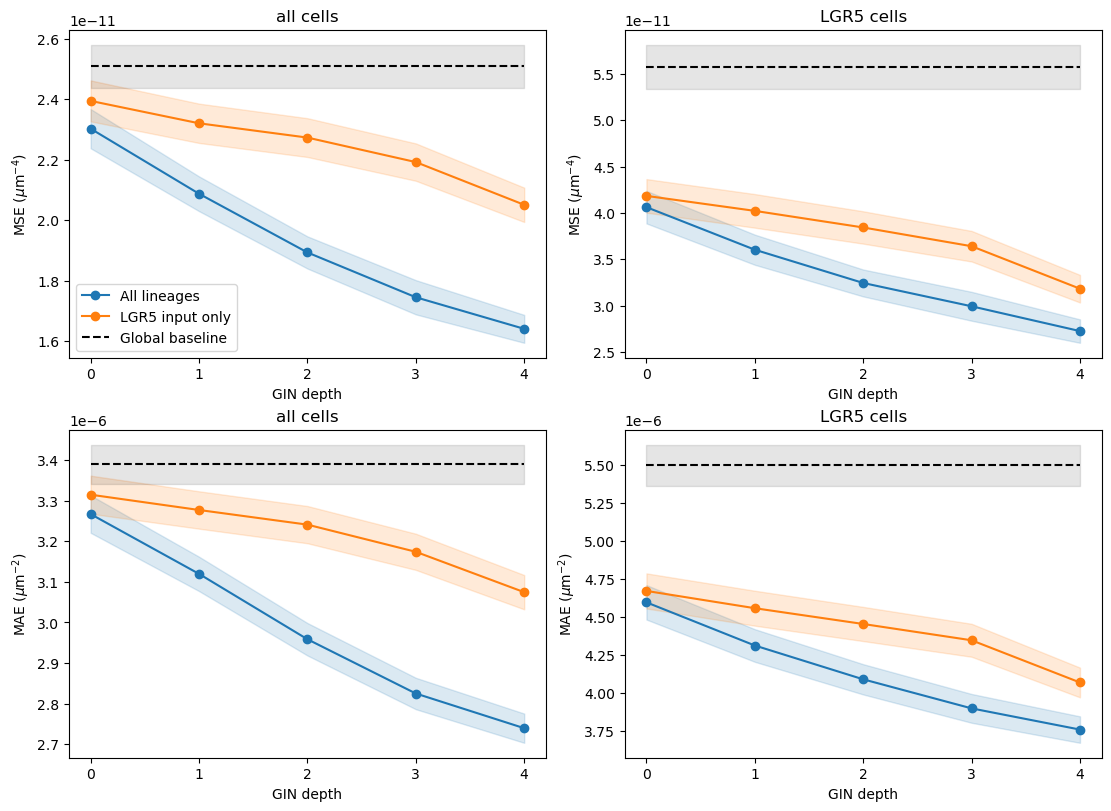

In [6]:
depth_out = STUDY_DIR/'depth_scan'
depth_out.mkdir(exist_ok=True)
chosen = metrics[(metrics.run_role=='main') | ((metrics.run_role=='subsets') & (metrics.subset=='LGR5'))].copy()
chosen = chosen[chosen.region=='full']
depth_rows = []
for scope in ['all_cells','LGR5_cells']:
    all_scope = 'all_cells' if scope=='all_cells' else 'lineage:LGR5'
    reduced_scope = 'all_cells' if scope=='all_cells' else 'retained_lineages'
    for label, frame in [('All lineages',chosen[(chosen.run_role=='main')&(chosen.scope==all_scope)]),
                         ('LGR5 input only',chosen[(chosen.run_role=='subsets')&(chosen.scope==reduced_scope)])]:
        f=frame.copy();f['evaluation']=scope;f['model']=label;depth_rows.append(f)
depth_scores=pd.concat(depth_rows,ignore_index=True)
depth_scores.to_csv(depth_out/'depth_metrics.csv',index=False)
fig,axes=plt.subplots(2,2,figsize=(11,8),layout='constrained')
for col,scope in enumerate(['all_cells','LGR5_cells']):
    for row,metric in enumerate(['mse','mae']):
        ax=axes[row,col];f=depth_scores[depth_scores.evaluation==scope]
        for label,g in f.groupby('model',sort=False):
            curve=summarize(g,'depth',metric).sort_values('depth')
            line,=ax.plot(curve.depth,curve['mean'],'o-',label=label)
            ax.fill_between(curve.depth,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color=line.get_color(),alpha=.16)
        base=summarize(f[f.model=='All lineages'],'depth','baseline_'+metric)
        ax.plot(base.depth,base['mean'],'k--',label='Global baseline')
        ax.fill_between(base.depth,base['mean']-base['sem'],base['mean']+base['sem'],color='k',alpha=.10)
        ax.set(title=scope.replace('_',' '),xlabel='GIN depth',ylabel=METRIC_LABELS[metric],xticks=DEPTHS)
axes[0,0].legend();save_figure(fig,depth_out/'depth_metrics')


## All-marker model evaluated by lineage
Each panel contains only cells with that original exclusive identity, including Unassigned. Show the model and its baseline on the same cells; absent identities contribute no organoid row. All panels share the same y-limits within each metric figure, including the uncertainty bands. The dotted purple curve repeats the same all-marker GIN evaluated on the full cell population in every panel; it is not a lineage-specific baseline. Its underlying rows are included as All lineages in lineage_depth_metrics.csv.

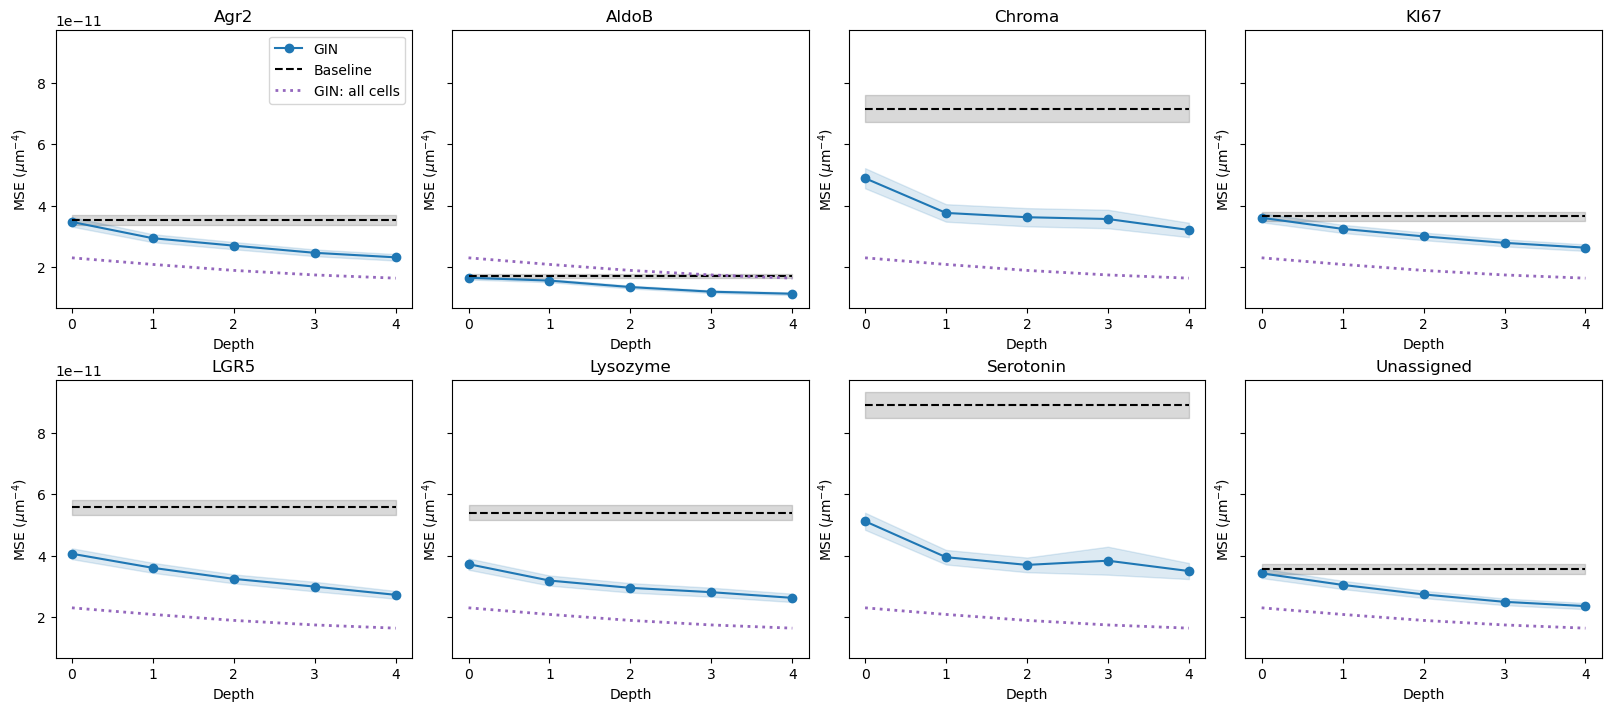

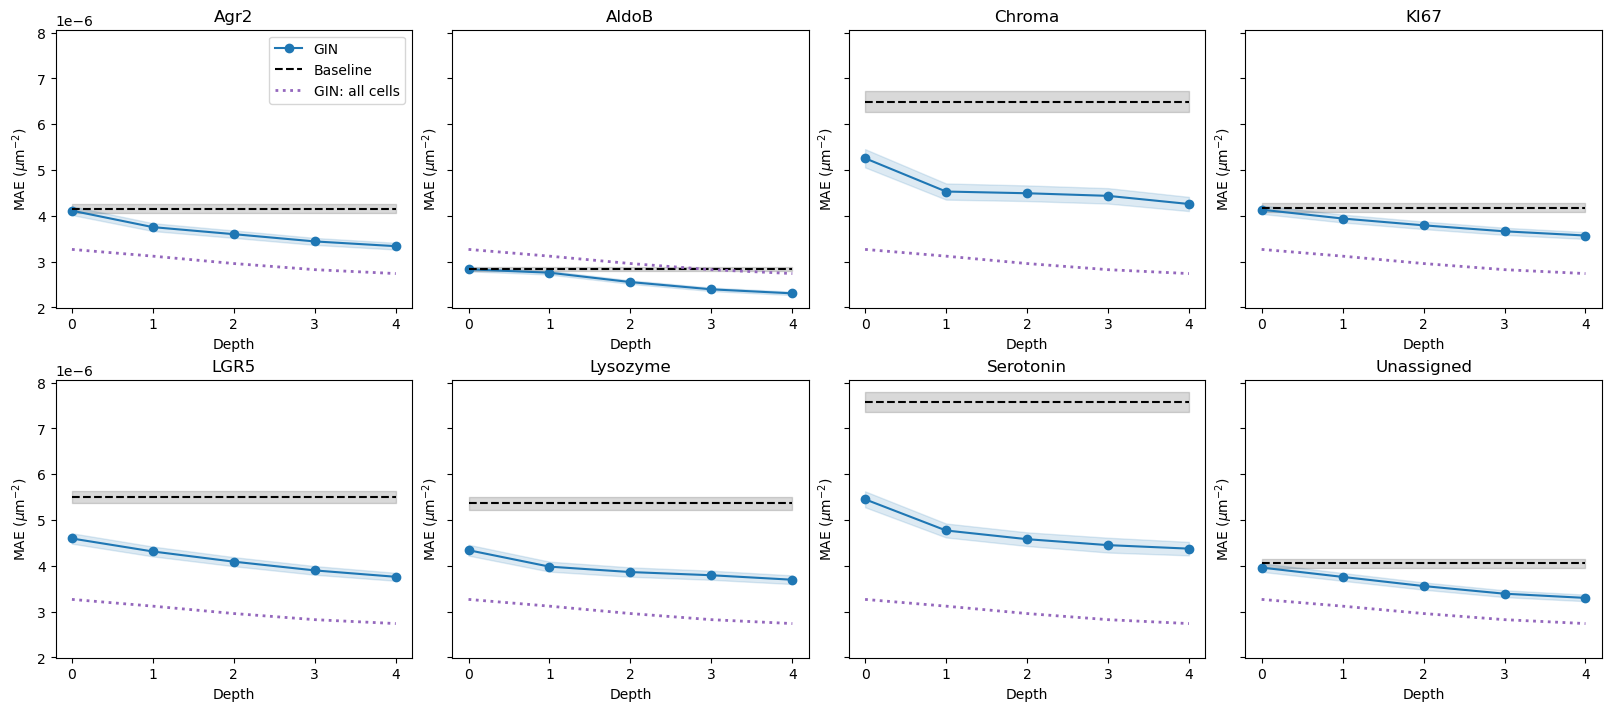

In [7]:
lineage_scores=metrics[(metrics.run_role=='main') & (metrics.region=='full') & metrics.scope.str.startswith('lineage:')].copy()
lineage_scores['lineage']=lineage_scores.scope.str.removeprefix('lineage:')
overall_scores = metrics[(metrics.run_role=='main') & (metrics.region=='full') & (metrics.scope=='all_cells')].copy()
overall_scores['lineage'] = 'All lineages'
pd.concat([lineage_scores,overall_scores],ignore_index=True).to_csv(depth_out/'lineage_depth_metrics.csv',index=False)
for metric in ['mse','mae']:
    fig,axes=plt.subplots(2,4,figsize=(16,7),sharey=True,layout='constrained')
    for ax,name in zip(axes.flat,identity_names):
        f=lineage_scores[lineage_scores.lineage==name]
        for value,label,color in [(metric,'GIN','tab:blue'),('baseline_'+metric,'Baseline','black')]:
            curve=summarize(f,'depth',value).sort_values('depth')
            ax.plot(curve.depth,curve['mean'],'o-' if label=='GIN' else '--',label=label,color=color)
            ax.fill_between(curve.depth,curve['mean']-curve['sem'],curve['mean']+curve['sem'],color=color,alpha=.15)
        overall = summarize(overall_scores,'depth',metric).sort_values('depth')
        ax.plot(overall.depth,overall['mean'],':',color='tab:purple',lw=2,label='GIN: all cells')
        ax.set(title=name,xlabel='Depth',ylabel=METRIC_LABELS[metric],xticks=DEPTHS)
    axes.flat[0].legend();save_figure(fig,depth_out/f'lineage_depth_{metric}')


## Subset models: evaluation on all cells
Compare depth 0 (purple squares) and depth 2 (blue circles), each as organoid-mean error ± SEM, for every subset and the all-marker category. The first three panels show full, legacy budded-crypt, and budded-neck errors. The dashed orange reference remains the **depth-2 all-marker** error; the baseline is a black dashed line with a ±SEM band.

The fourth panel shows crypt-minus-neck relative improvement for each depth, with paired organoid-bootstrap 95% intervals. Both depths use the same baseline-to-depth-2-all-marker denominator, so a weaker reference is not substituted for depth 0. The all-marker depth-2 contrast is zero by construction; depth 0 need not be. All exports include a `depth` column.

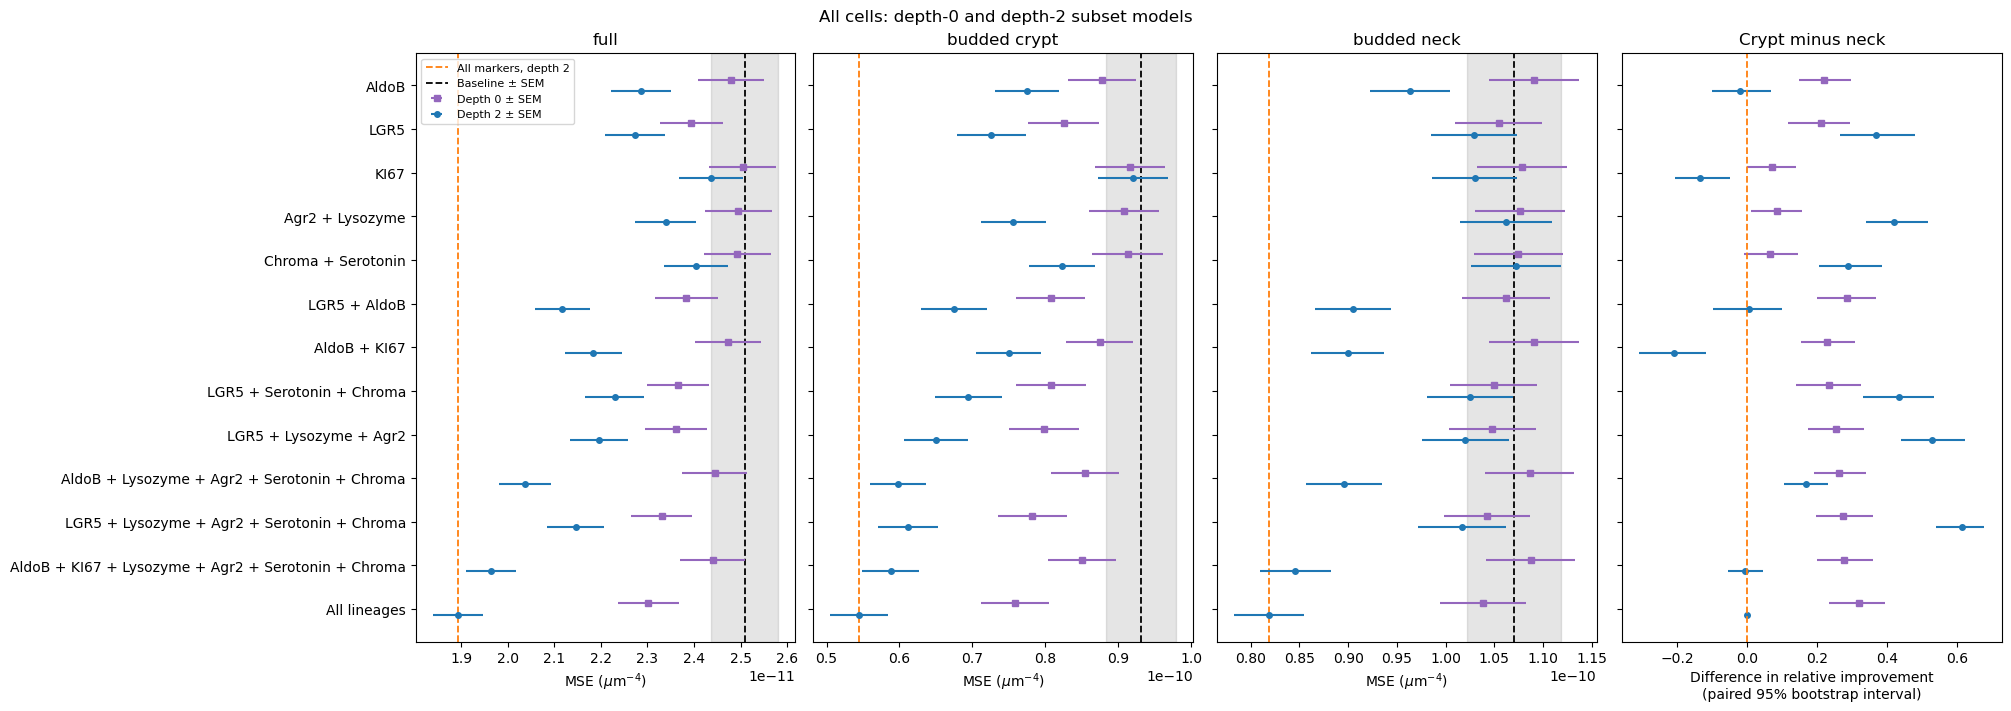

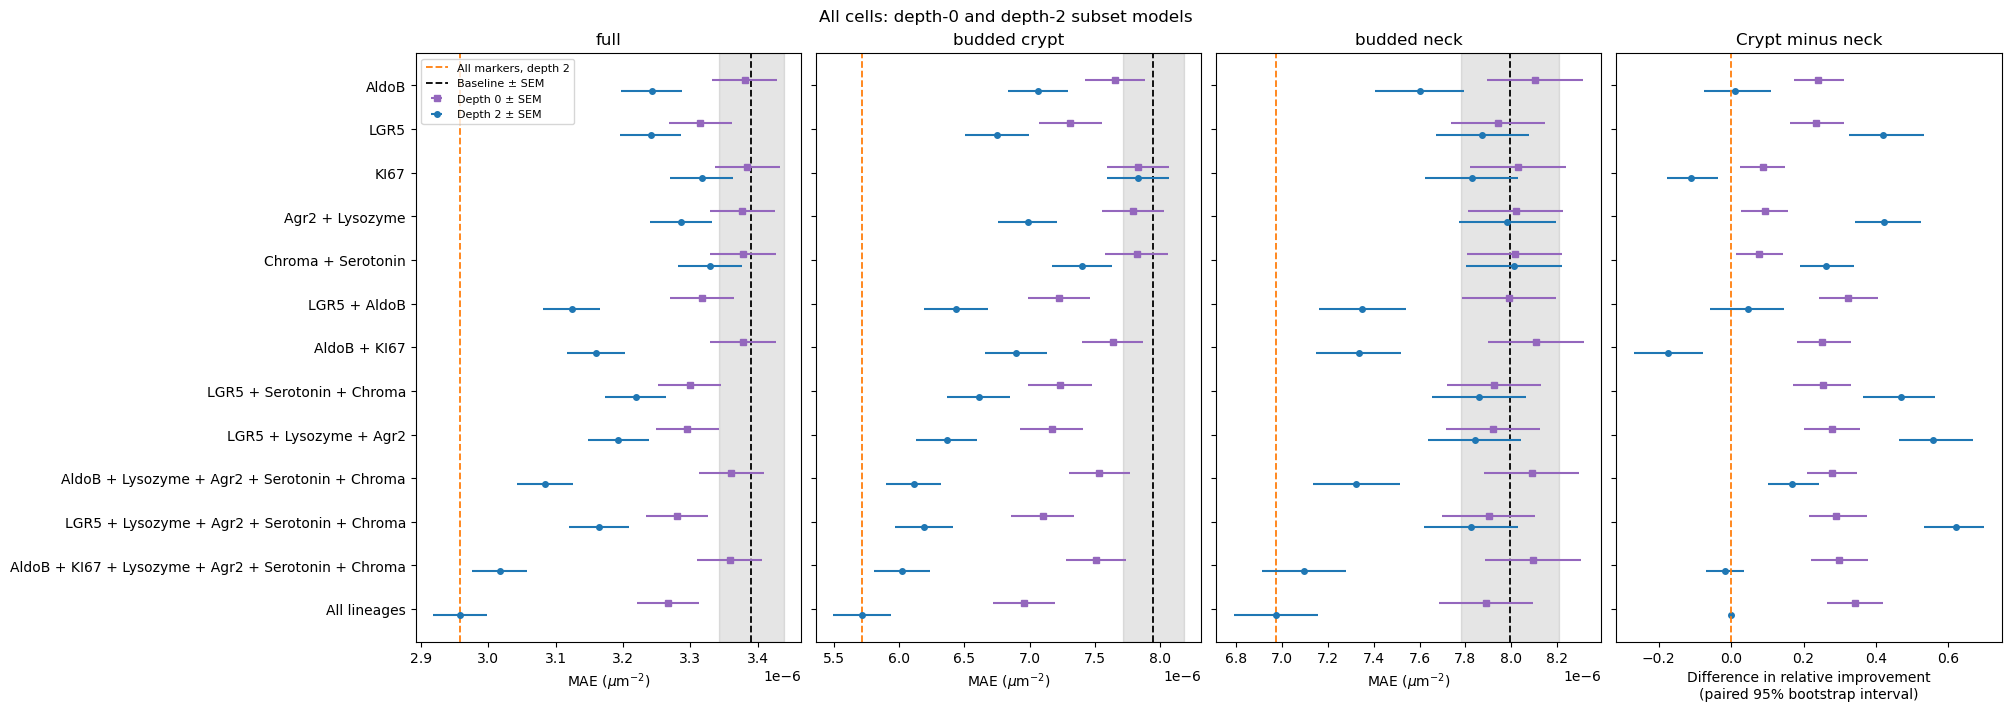

In [8]:
subset_out = STUDY_DIR/'lineage_subsets'
subset_out.mkdir(exist_ok=True)
subset_scores = metrics[(metrics.run_role=='subsets') & metrics.depth.isin(SUBSET_DEPTHS)].copy()
reference = metrics[(metrics.run_role=='main') & (metrics.depth==2)]
ref_rows = []
for row in subset_scores.itertuples():
    ref = reference[(reference.organoid_str==row.organoid_str) & (reference.fold==row.fold) & (reference.region==row.region)]
    if row.scope=='all_cells':
        ref = ref[ref.scope=='all_cells']
    else:
        names = subsets.settings['marker_subsets'][row.subset]
        ref = ref[ref.scope.isin(['lineage:'+name for name in names])]
    assert int(ref.n_cells.sum())==row.n_cells
    ref_rows.append({metric:np.average(ref[metric],weights=ref.n_cells) for metric in ['mse','mae']})
for metric in ['mse','mae']:
    subset_scores['reference_'+metric] = [row[metric] for row in ref_rows]

# The all-marker category includes every identity at each requested depth.
all_rows = metrics[(metrics.run_role=='main') & metrics.depth.isin(SUBSET_DEPTHS) & (metrics.scope=='all_cells')].copy()
all_rows['subset'] = 'all'
for metric in ['mse','mae']:
    ref_lookup = reference[reference.scope=='all_cells'].set_index(['organoid_str','fold','seed','region'])[metric]
    all_rows['reference_'+metric] = ref_lookup.reindex(pd.MultiIndex.from_frame(all_rows[['organoid_str','fold','seed','region']])).to_numpy()
subset_scores = pd.concat([subset_scores, all_rows,
    all_rows.assign(scope='retained_lineages')],ignore_index=True)
subset_order = [*subsets.settings['marker_subsets'], 'all']
subset_labels = {key:' + '.join(values) for key,values in subsets.settings['marker_subsets'].items()}
subset_labels['all'] = 'All lineages'
subset_scores['subset_order'] = subset_scores.subset.map(dict(zip(subset_order,range(len(subset_order)))))
subset_scores['subset_label'] = subset_scores.subset.map(subset_labels)
subset_scores.to_csv(subset_out/'subset_metrics.csv',index=False)
regions = ['full','budded_crypt','budded_neck']

# Exact plot values: all summaries first average repeated predictions per organoid.
summary_rows = []
for (scope,region,subset,depth),frame in subset_scores.groupby(['scope','region','subset','depth']):
    for metric in ['mse','mae']:
        for model,column in [('subset',metric),('baseline','baseline_'+metric),('all_marker','reference_'+metric)]:
            result = summarize(frame,[],column).iloc[0]
            summary_rows.append(dict(scope=scope,region=region,subset=subset,depth=depth,subset_label=subset_labels[subset],
                subset_order=subset_order.index(subset),metric=metric,model=model,
                mean=result['mean'],sem=result['sem'],n_organoids=int(result['count']),
                units='um^-4' if metric=='mse' else 'um^-2'))
plot_summary = pd.DataFrame(summary_rows)
plot_summary.to_csv(subset_out/'subset_plot_summary.csv',index=False)

# Only all-cell crypt-minus-neck improvement is requested.
rng = np.random.default_rng(BOOTSTRAP_SEED)
contrast_rows = []
for (subset,depth),frame in subset_scores[subset_scores.scope=='all_cells'].groupby(['subset','depth']):
    ids = frame.organoid_str.unique()
    index = {oid:i for i,oid in enumerate(ids)}
    # Identical resampled organoids across depths for this subset.
    rng = np.random.default_rng(BOOTSTRAP_SEED + subset_order.index(subset))
    bootstrap = rng.multinomial(len(ids),np.full(len(ids),1/len(ids)),size=BOOTSTRAP_REPEATS)
    for metric in ['mse','mae']:
        point = {}; samples = {}
        for region in ['budded_crypt','budded_neck']:
            g = frame[frame.region==region]
            model = g[metric].to_numpy(); base = g['baseline_'+metric].to_numpy(); ref = g['reference_'+metric].to_numpy()
            denominator = base.mean()-ref.mean()
            point[region] = (base.mean()-model.mean())/denominator if len(g) and abs(denominator)>1e-12*max(abs(base.mean()),abs(ref.mean()),1e-30) else np.nan
            weights = bootstrap[:,[index[oid] for oid in g.organoid_str]]
            numerator = weights@(base-model); denominator_b = weights@(base-ref)
            samples[region] = np.divide(numerator,denominator_b,out=np.full(BOOTSTRAP_REPEATS,np.nan),
                where=abs(denominator_b)>1e-12*np.maximum(weights@abs(base),1e-30))
        value = point['budded_crypt']-point['budded_neck']
        draws = samples['budded_crypt']-samples['budded_neck']
        finite = draws[np.isfinite(draws)]
        low,high = np.quantile(finite,[.025,.975]) if len(finite) else (np.nan,np.nan)
        contrast_rows.append(dict(scope='all_cells',subset=subset,depth=depth,subset_label=subset_labels[subset],
            subset_order=subset_order.index(subset),metric=metric,region='crypt_minus_neck',
            value=value,low=low,high=high,units='dimensionless'))
contrast = pd.DataFrame(contrast_rows)
contrast.to_csv(subset_out/'crypt_minus_neck_improvement.csv',index=False)

DEPTH_STYLES = {0:dict(color='tab:purple',marker='s',offset=-.13),
                2:dict(color='tab:blue',marker='o',offset=.13)}
y = np.arange(len(subset_order))
for metric in ['mse','mae']:
    fig,axes = plt.subplots(1,4,figsize=(20,7),sharey=True,layout='constrained')
    for ax,region in zip(axes[:3],regions):
        f = plot_summary[(plot_summary.scope=='all_cells') & (plot_summary.region==region) & (plot_summary.metric==metric)]
        for depth in SUBSET_DEPTHS:
            style = DEPTH_STYLES[depth]
            points = f[(f.model=='subset') & (f.depth==depth)].set_index('subset').reindex(subset_order)
            ax.errorbar(points['mean'],y+style['offset'],xerr=points['sem'],fmt=style['marker'],ms=4,
                color=style['color'],label=f'Depth {depth} ± SEM',zorder=3)
        reference_point = f[(f.subset=='all') & (f.model=='all_marker') & (f.depth==2)].iloc[0]['mean']
        baseline = f[(f.subset=='all') & (f.model=='baseline') & (f.depth==2)].iloc[0]
        ax.axvline(reference_point,color='tab:orange',ls='--',lw=1.3,label='All markers, depth 2')
        ax.axvspan(baseline['mean']-baseline['sem'],baseline['mean']+baseline['sem'],color='black',alpha=.10)
        ax.axvline(baseline['mean'],color='black',ls='--',lw=1.3,label='Baseline ± SEM')
        ax.set(title=region.replace('_',' '),xlabel=METRIC_LABELS[metric],yticks=y,
               yticklabels=[subset_labels[key] for key in subset_order])
    ax = axes[3]
    for depth in SUBSET_DEPTHS:
        f = contrast[(contrast.metric==metric)&(contrast.depth==depth)].set_index('subset').reindex(subset_order)
        style = DEPTH_STYLES[depth]
        ax.hlines(y+style['offset'],f.low,f.high,color=style['color'])
        ax.plot(f.value,y+style['offset'],style['marker'],ms=4,color=style['color'])
    ax.axvline(0,color='tab:orange',ls='--',lw=1.3)
    ax.set(title='Crypt minus neck',xlabel='Difference in relative improvement\n(paired 95% bootstrap interval)')
    axes[0].invert_yaxis();axes[0].legend(fontsize=8)
    fig.suptitle('All cells: depth-0 and depth-2 subset models')
    save_figure(fig,subset_out/f'all_cells_{metric}')


## Subset models: evaluation on retained lineages
Both panels evaluate the **full** category on the same retained cells for depths 0 and 2. The left panel shows each subset model's mean ± SEM and the range between the matched **depth-2 all-marker** mean (orange endpoint) and baseline mean (black endpoint). The right panel rescales each depth's error as (baseline − subset)/(baseline − depth-2 all-marker), holding the reference constant across depths. The All lineages row includes the full population, including Unassigned.

Error bars on the right are the subset SEM divided by the absolute reference gap; they hold reference means fixed and do not include uncertainty in that gap. Ratios use organoid-mean errors, are not clipped to [0,1], and remain missing if undefined. Tables include depth, the three means, denominator, raw SEM, and normalized SEM.

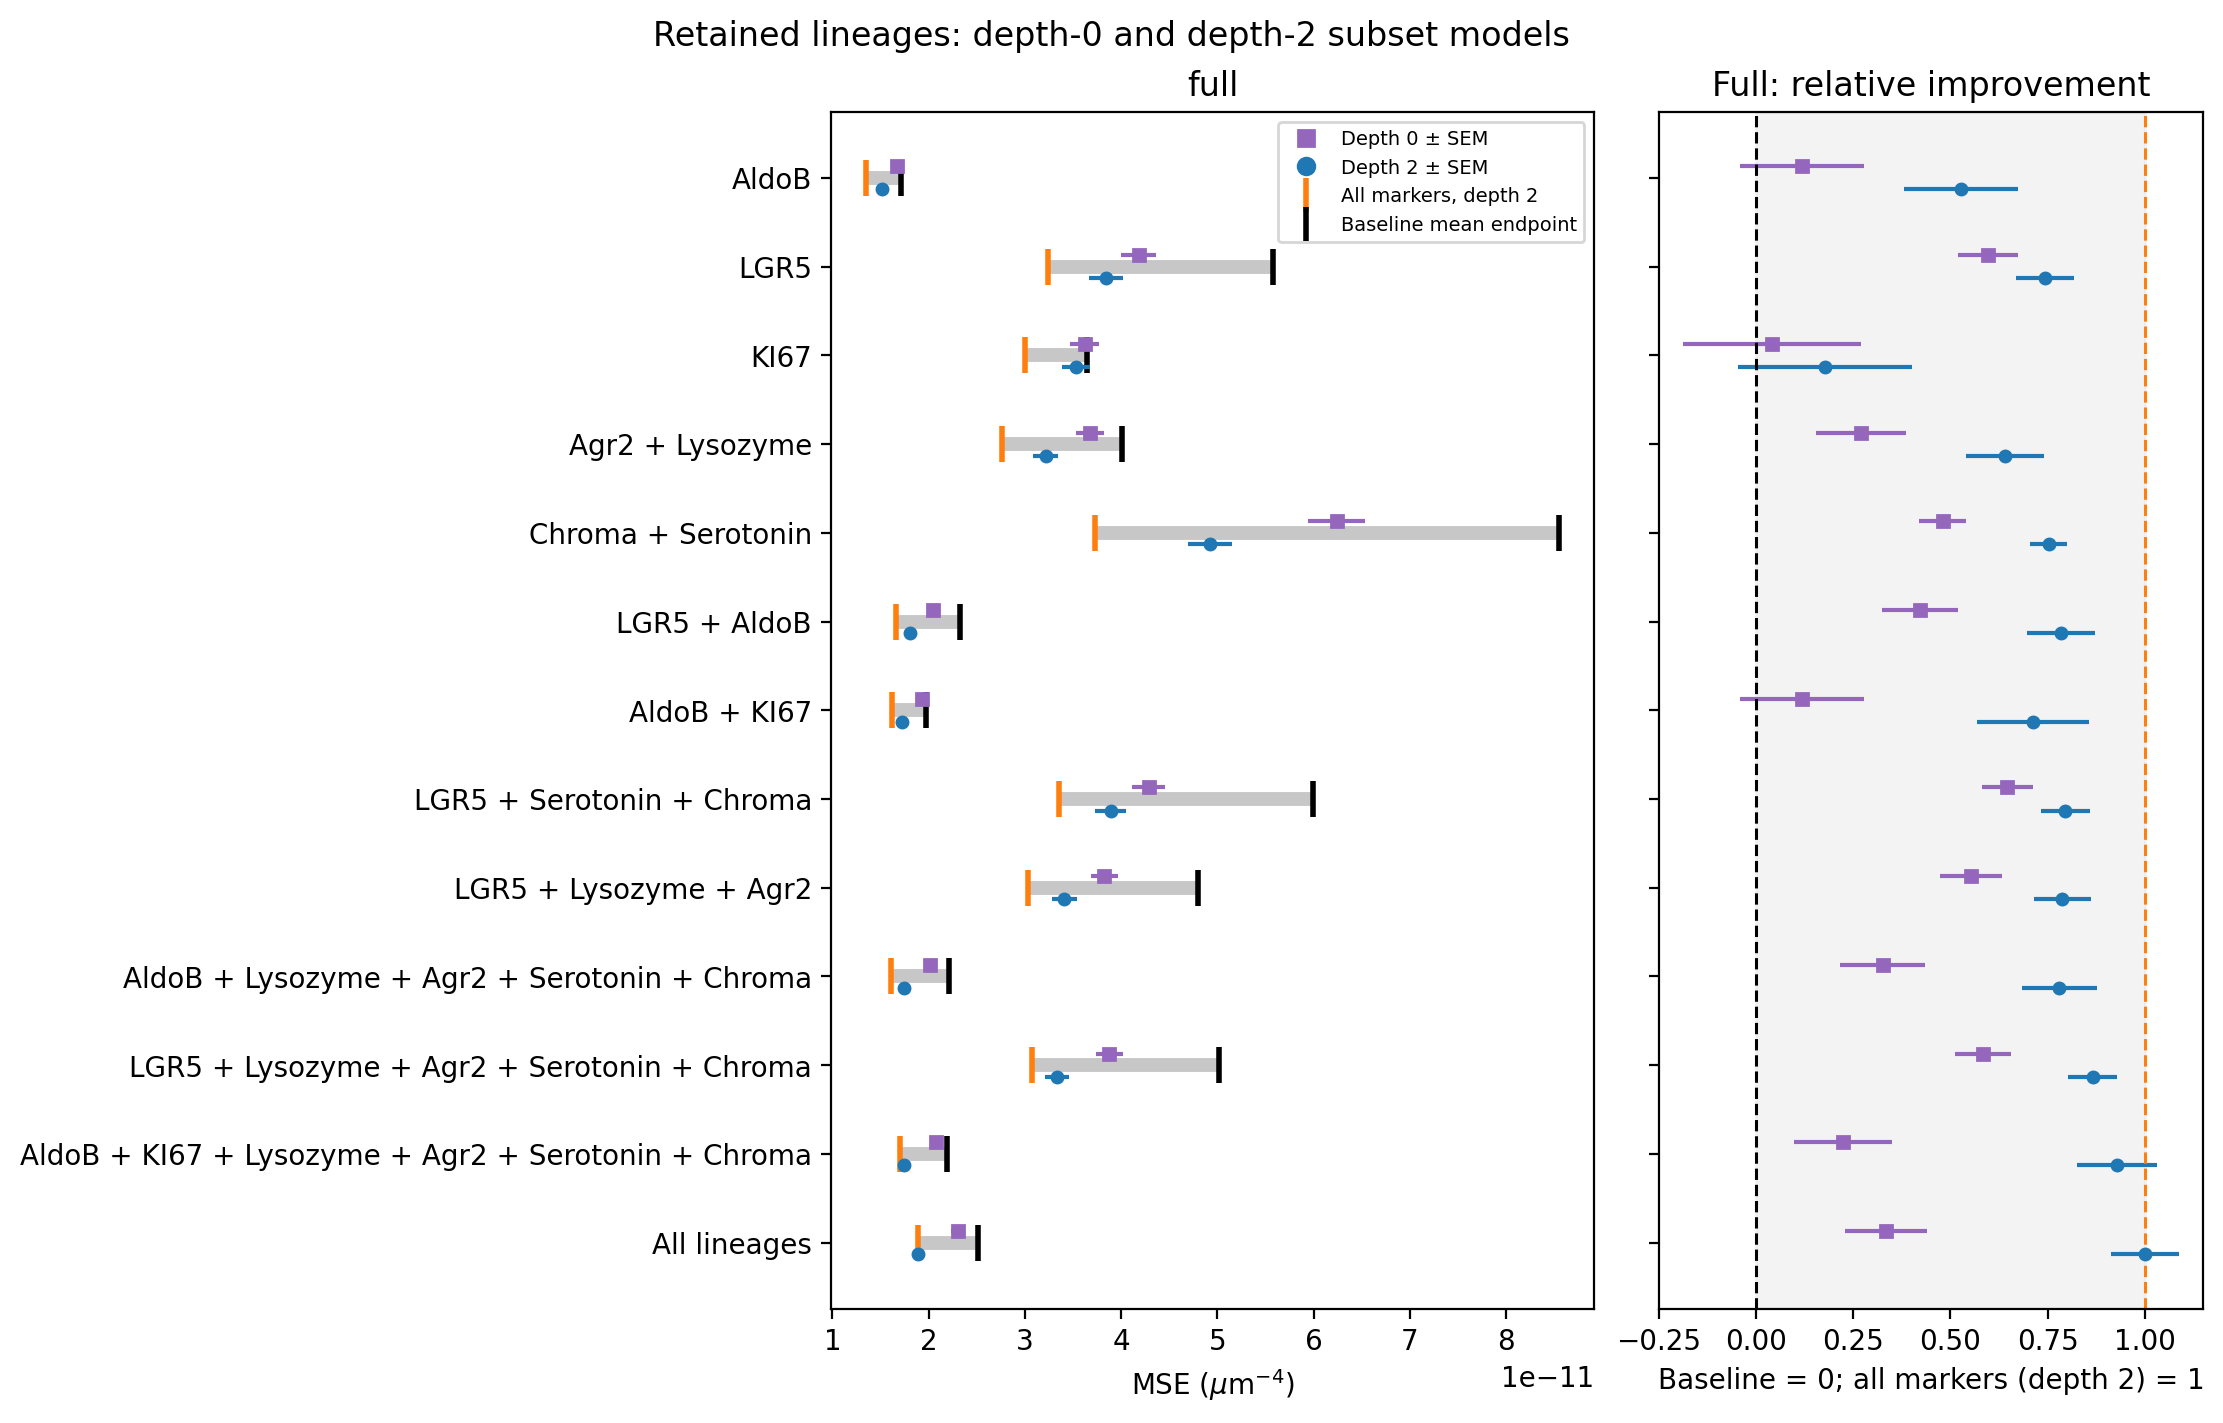

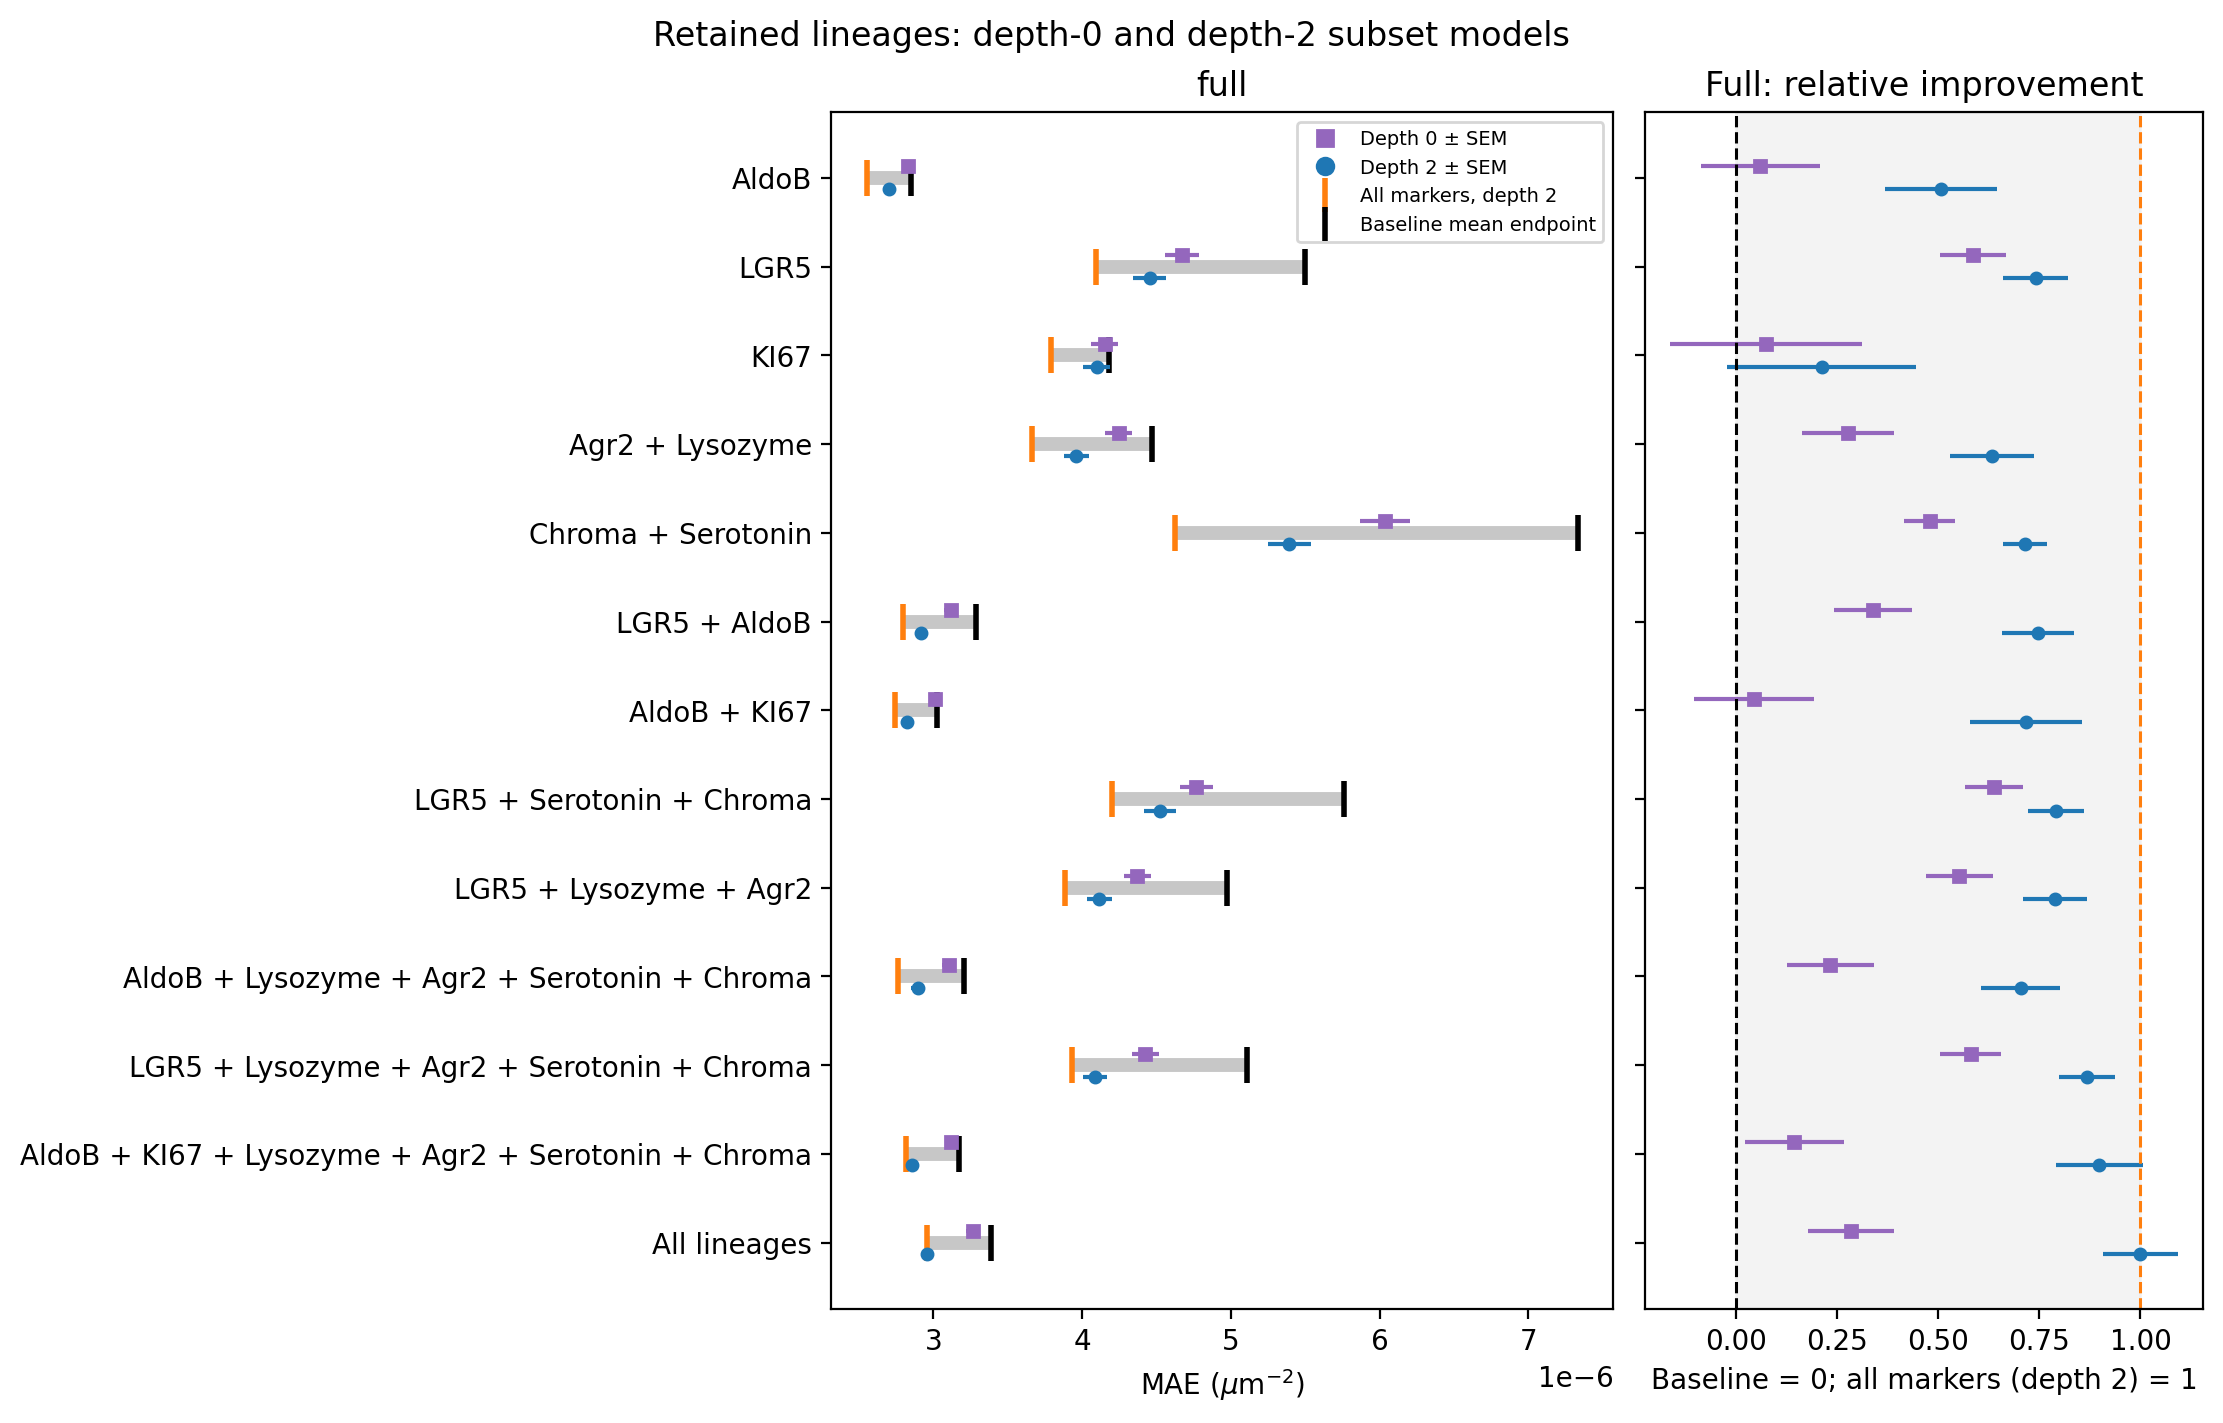

In [9]:
from matplotlib.lines import Line2D
normalized_rows = []
for metric in ['mse','mae']:
    fig,axes = plt.subplots(1,2,figsize=(11,7),sharey=True,gridspec_kw={'width_ratios':[1.4,1]},layout='constrained')
    f = plot_summary[(plot_summary.scope=='retained_lineages') & (plot_summary.region=='full') & (plot_summary.metric==metric)]
    baseline = f[(f.model=='baseline') & (f.depth==2)].set_index('subset').reindex(subset_order)
    reference = f[(f.model=='all_marker') & (f.depth==2)].set_index('subset').reindex(subset_order)
    y = np.arange(len(subset_order))
    axes[0].hlines(y,np.minimum(reference['mean'],baseline['mean']),np.maximum(reference['mean'],baseline['mean']),color='0.78',lw=5,zorder=1)
    axes[0].plot(reference['mean'],y,ls='none',marker='|',ms=13,mew=2,color='tab:orange',zorder=2)
    axes[0].plot(baseline['mean'],y,ls='none',marker='|',ms=13,mew=2,color='black',zorder=2)
    intervals = []
    for depth in SUBSET_DEPTHS:
        style = DEPTH_STYLES[depth]
        points = f[(f.model=='subset') & (f.depth==depth)].set_index('subset').reindex(subset_order)
        for model,expected in [('baseline',baseline),('all_marker',reference)]:
            actual = f[(f.model==model)&(f.depth==depth)].set_index('subset').reindex(subset_order)
            np.testing.assert_allclose(actual['mean'],expected['mean'],rtol=1e-6,atol=0)
        axes[0].errorbar(points['mean'],y+style['offset'],xerr=points['sem'],fmt=style['marker'],ms=4,color=style['color'],zorder=3)
        denominator = baseline['mean']-reference['mean']
        tolerance = 1e-12*np.maximum(np.maximum(abs(baseline['mean']),abs(reference['mean'])),1e-30)
        defined = abs(denominator)>tolerance
        relative = ((baseline['mean']-points['mean'])/denominator).where(defined)
        relative_sem = (points['sem']/abs(denominator)).where(defined)
        axes[1].errorbar(relative,y+style['offset'],xerr=relative_sem,fmt=style['marker'],ms=4,
            color=style['color'],label=f'Depth {depth} ± rescaled SEM')
        for subset in subset_order:
            intervals.append(dict(region='full',subset=subset,depth=depth,subset_label=subset_labels[subset],
                subset_order=subset_order.index(subset),metric=metric,
                subset_mean=points.loc[subset,'mean'],subset_sem=points.loc[subset,'sem'],
                all_marker_endpoint=reference.loc[subset,'mean'],reference_depth=2,baseline_endpoint=baseline.loc[subset,'mean'],
                units='um^-4' if metric=='mse' else 'um^-2'))
            normalized_rows.append(dict(scope='retained_lineages',region='full',subset=subset,depth=depth,
                subset_label=subset_labels[subset],subset_order=subset_order.index(subset),metric=metric,
                subset_mean=points.loc[subset,'mean'],baseline_mean=baseline.loc[subset,'mean'],
                all_marker_mean=reference.loc[subset,'mean'],reference_depth=2,denominator=denominator.loc[subset],
                denominator_positive=bool(denominator.loc[subset]>0),defined=bool(defined.loc[subset]),
                relative_improvement=relative.loc[subset],subset_sem=points.loc[subset,'sem'],
                relative_improvement_sem=relative_sem.loc[subset],units='dimensionless'))
    pd.DataFrame(intervals).to_csv(subset_out/f'retained_lineages_{metric}_intervals.csv',index=False)
    axes[0].set(title='full',xlabel=METRIC_LABELS[metric],yticks=y,yticklabels=[subset_labels[key] for key in subset_order])
    axes[1].axvspan(0,1,color='0.9',alpha=.45,zorder=0)
    axes[1].axvline(0,color='black',ls='--',lw=1.1,label='Baseline')
    axes[1].axvline(1,color='tab:orange',ls='--',lw=1.1,label='All markers, depth 2')
    axes[1].set(title='Full: relative improvement',xlabel='Baseline = 0; all markers (depth 2) = 1',
        yticks=y,yticklabels=[subset_labels[key] for key in subset_order])
    handles = [Line2D([],[],marker=DEPTH_STYLES[d]['marker'],ls='none',color=DEPTH_STYLES[d]['color'],label=f'Depth {d} ± SEM') for d in SUBSET_DEPTHS]
    handles += [Line2D([],[],marker='|',ms=12,mew=2,ls='none',color='tab:orange',label='All markers, depth 2'),
        Line2D([],[],marker='|',ms=12,mew=2,ls='none',color='black',label='Baseline mean endpoint')]
    axes[0].invert_yaxis();axes[0].legend(handles=handles,fontsize=7)
    fig.suptitle('Retained lineages: depth-0 and depth-2 subset models')
    save_figure(fig,subset_out/f'retained_lineages_{metric}')
pd.DataFrame(normalized_rows).to_csv(subset_out/'retained_lineages_relative_improvement.csv',index=False)


## Exemplar meshes: one figure per input subset
Use the organoid’s held-out fold automatically. Each of two figures shows ground truth once, followed by predictions at depths 0, 2 and 4. All eight panels share one curvature scale. The six VTP exports preserve the numerical fields; figure_panels.csv specifies their panel order, field names, camera and shared color limits so the figures can be reconstructed.

In [10]:
from src.plotting.mesh_plots import project_node_quantities_to_mesh
from organograph.plotting.meshes import plot_organoid_mesh
from plotly.subplots import make_subplots
import vtk
from vtk.util.numpy_support import numpy_to_vtk
mesh_out=STUDY_DIR/'prediction_meshes';mesh_out.mkdir(exist_ok=True)
projections=[]
for role,run,subset in [('all',main,'all'),('LGR5',subsets,'LGR5')]:
    split=next(s for s in json.loads((run.directory/'splits.json').read_text()) if EXEMPLAR in s['validation'])
    assert EXEMPLAR not in split['train']
    for depth in MESH_DEPTHS:
        record=run.records[(run.records.fold==split['fold'])&(run.records.depth==depth)&(run.records.subset==subset)].iloc[0]
        selection=run.select(record.key,device=DEVICE)
        graph=next(g for g in selection['groups']['val'] if g.organoid_str==EXEMPLAR)
        selection['groups']={'val':[graph]}
        frame=prediction_table(selection,device=DEVICE)
        projection=project_node_quantities_to_mesh(raw_graphs[EXEMPLAR],node_true=frame.y_true.to_numpy()*CURVATURE_SCALE,node_pred=frame.y_pred.to_numpy()*CURVATURE_SCALE)
        projections.append((role,depth,record.key,projection))
        del selection
        run._data_cache.clear()
limits=max(np.nanmax(abs(p[field])) for _,_,_,p in projections for field in ['mesh_true','mesh_pred'])
for role,depth,key,projection in projections:
    mesh=projection['mesh'];points=vtk.vtkPoints();points.SetData(numpy_to_vtk(np.asarray(mesh.v),deep=True));faces=vtk.vtkCellArray()
    for face in np.asarray(mesh.f):
        faces.InsertNextCell(len(face))
        for vertex in face:faces.InsertCellPoint(int(vertex))
    poly=vtk.vtkPolyData();poly.SetPoints(points);poly.SetPolys(faces)
    owner=np.asarray(projection['vertex_owner']);ids=np.full(len(owner),-1,dtype=np.int32)
    original=annotation(EXEMPLAR).lineage.map(dict(zip(identity_names,range(len(identity_names))))).to_numpy()
    ids[owner>=0]=original[owner[owner>=0]]
    for name,values in [('true_curvature_um_minus2',projection['mesh_true']),('predicted_curvature_um_minus2',projection['mesh_pred']),('node_id',owner),('exclusive_lineage_id',ids)]:
        array=numpy_to_vtk(np.asarray(values),deep=True);array.SetName(name);poly.GetPointData().AddArray(array)
    writer=vtk.vtkXMLPolyDataWriter();writer.SetFileName(str(mesh_out/f'{role}_depth{depth}_{EXEMPLAR}.vtp'));writer.SetInputData(poly);writer.Write()
# One four-panel figure per input subset; common limits across both figures.
mesh_panel_rows = []
for role in ['all','LGR5']:
    selected = [(depth,key,projection) for saved_role,depth,key,projection in projections if saved_role==role]
    truth = selected[0][2]['mesh_true']
    for _,_,projection in selected:
        np.testing.assert_allclose(projection['mesh_true'],truth,equal_nan=True)
    panels = [('Ground truth',selected[0][2], 'mesh_true',None,None)] + [
        (f'Depth {depth}',projection,'mesh_pred',depth,key) for depth,key,projection in selected]
    fig = make_subplots(rows=1,cols=len(panels),specs=[[{'type':'scene'} for _ in panels]],
        subplot_titles=[panel[0] for panel in panels],horizontal_spacing=.015)
    for column,(label,projection,field,depth,key) in enumerate(panels,1):
        single = plot_organoid_mesh(projection['mesh'],vertex_values=projection[field],backend='plotly',
            colorscale='RdBu_r',center_at_zero=True,vmin=-limits,vmax=limits,
            show_colorbar=column==len(panels),view=MESH_VIEW)
        for trace in single.data:
            trace.update(cmin=-limits,cmax=limits,colorbar=dict(title='K (um^-2)',x=1.01))
            fig.add_trace(trace,row=1,col=column)
        scene_key = 'scene' if column==1 else f'scene{column}'
        scene = single.layout.scene.to_plotly_json()
        scene.pop('domain',None)
        fig.update_layout(**{scene_key:scene})
        mesh_panel_rows.append(dict(input_subset=role,panel=column,label=label,depth=depth,checkpoint=key,
            vtp_file=f'{role}_depth{selected[0][0] if depth is None else depth}_{EXEMPLAR}.vtp',
            point_field='true_curvature_um_minus2' if depth is None else 'predicted_curvature_um_minus2',
            color_min=-limits,color_max=limits,colorscale='RdBu_r',curvature_unit='um^-2',
            camera_azim=MESH_VIEW['azim'],camera_elev=MESH_VIEW['elev']))
    title = 'All lineages' if role=='all' else 'LGR5 input only'
    fig.update_layout(width=1600,height=470,title=f'{title}: {EXEMPLAR} (held-out fold)')
    fig.show()
pd.DataFrame(mesh_panel_rows).to_csv(mesh_out/'figure_panels.csv',index=False)
(mesh_out/'fields.json').write_text(json.dumps(dict(organoid=EXEMPLAR,lineage_ids=dict(enumerate(identity_names)),curvature_unit='um^-2',coordinate_note='Display-normalized mesh coordinates; unchanged topology.',checkpoints=[key for _,_,key,_ in projections]),indent=2))


578